In [21]:

import numpy as np            
import pandas as pd            
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn        
from sklearn.model_selection import train_test_split

In [7]:
X_train = pd.read_csv('x_train.csv')
y_train = pd.read_csv('y_train.csv')
X_test  = pd.read_csv('x_test.csv')


# On s'assure que la ligne 1 de X_train correspond bien à la ligne 1 de y_train
# en les triant par leur identifiant unique ('ID').
X_train = X_train.sort_values('ID').reset_index(drop=True)
y_train = y_train.sort_values('ID').reset_index(drop=True)

# 3. Affichage de la taille des données (nombre de lignes et de colonnes)
print(f'X_train : {X_train.shape}   →  {X_train.shape[0]:,} échantillons, {X_train.shape[1]} colonnes')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (202933, 14)   →  202,933 échantillons, 14 colonnes
y_train : (202933, 24)
X_test  : (134673, 14)


In [8]:
X_train.head(5)

,ID,Humidity,M12,M13,M14,M15,M4,M5,M6,M7,R,S1,S2,S3
0,0,0.098160,-0.175981,-0.086469,-0.041465,-0.021153,0.197597,0.054646,-0.009277,0.001855,1.007242,1.013007,1.000563,0.999397
1,1,0.000307,-0.066416,0.036071,0.032636,-0.000573,2.568494,1.883142,0.779251,0.262231,0.971428,0.996735,1.002226,1.013063
2,2,0.000388,0.190943,0.187540,0.143680,0.092635,-0.147460,-0.021174,0.040079,0.065790,1.302238,0.905275,0.953600,0.986347
3,3,0.761003,-0.151393,-0.083723,-0.048982,-0.018259,0.045380,0.102427,0.012915,0.004453,1.013741,1.004315,1.012301,1.009465
4,4,0.107808,0.074818,0.042692,0.026169,0.019134,-0.056284,-0.011193,0.010233,0.012205,0.998659,1.005154,1.000096,0.999553


In [9]:

y_train.head(5)

,ID,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c14,c15,c16,c17,c18,c19,c20,c21,c22,c23
0,0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,1,0.000000,0.0,0.176471,0.176471,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.176471,0.0,0.0,0.176471,0.000000
2,2,0.128465,0.0,0.128465,0.128465,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.128465,0.000000,0.0,0.0,0.128465,0.000000
3,3,0.000000,0.0,0.263736,0.263736,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.263736,0.263736
4,4,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_5944\748969453.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prevalence.index, y=prevalence.values, palette='viridis')


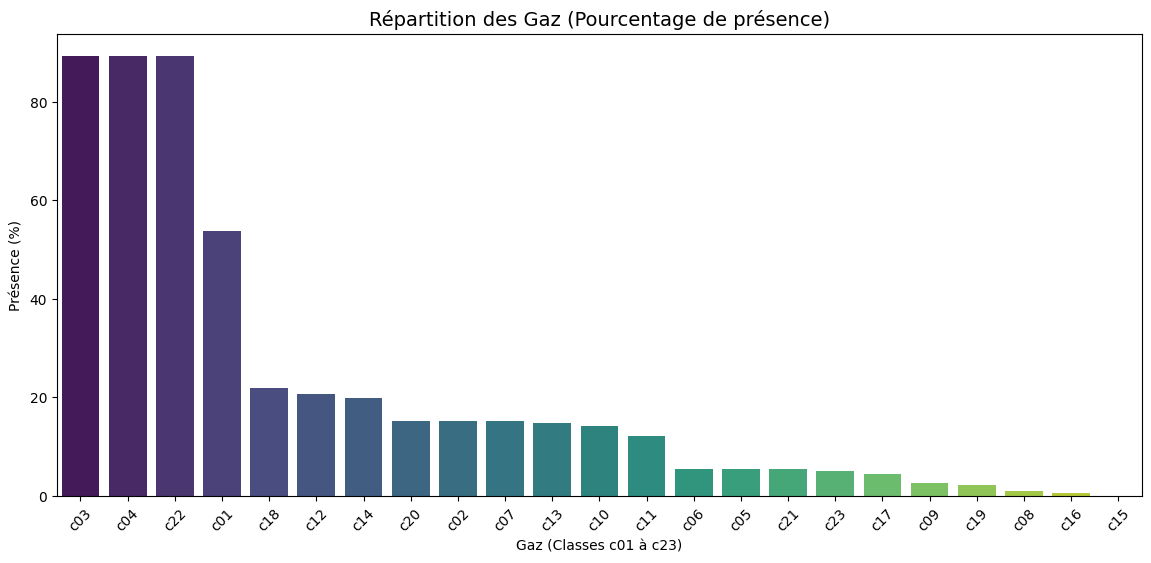

In [10]:
# Diagramme de répartition des gaz (cibles)
# Calcul du pourcentage de présence pour chaque gaz (valeur > 0)
target_cols = [c for c in y_train.columns if c != 'ID']
prevalence = (y_train[target_cols] > 0).mean().sort_values(ascending=False) * 100

plt.figure(figsize=(14, 6))
sns.barplot(x=prevalence.index, y=prevalence.values, palette='viridis')
plt.title('Répartition des Gaz (Pourcentage de présence)', fontsize=14)
plt.ylabel('Présence (%)')
plt.xlabel('Gaz (Classes c01 à c23)')
plt.xticks(rotation=45)
plt.show()

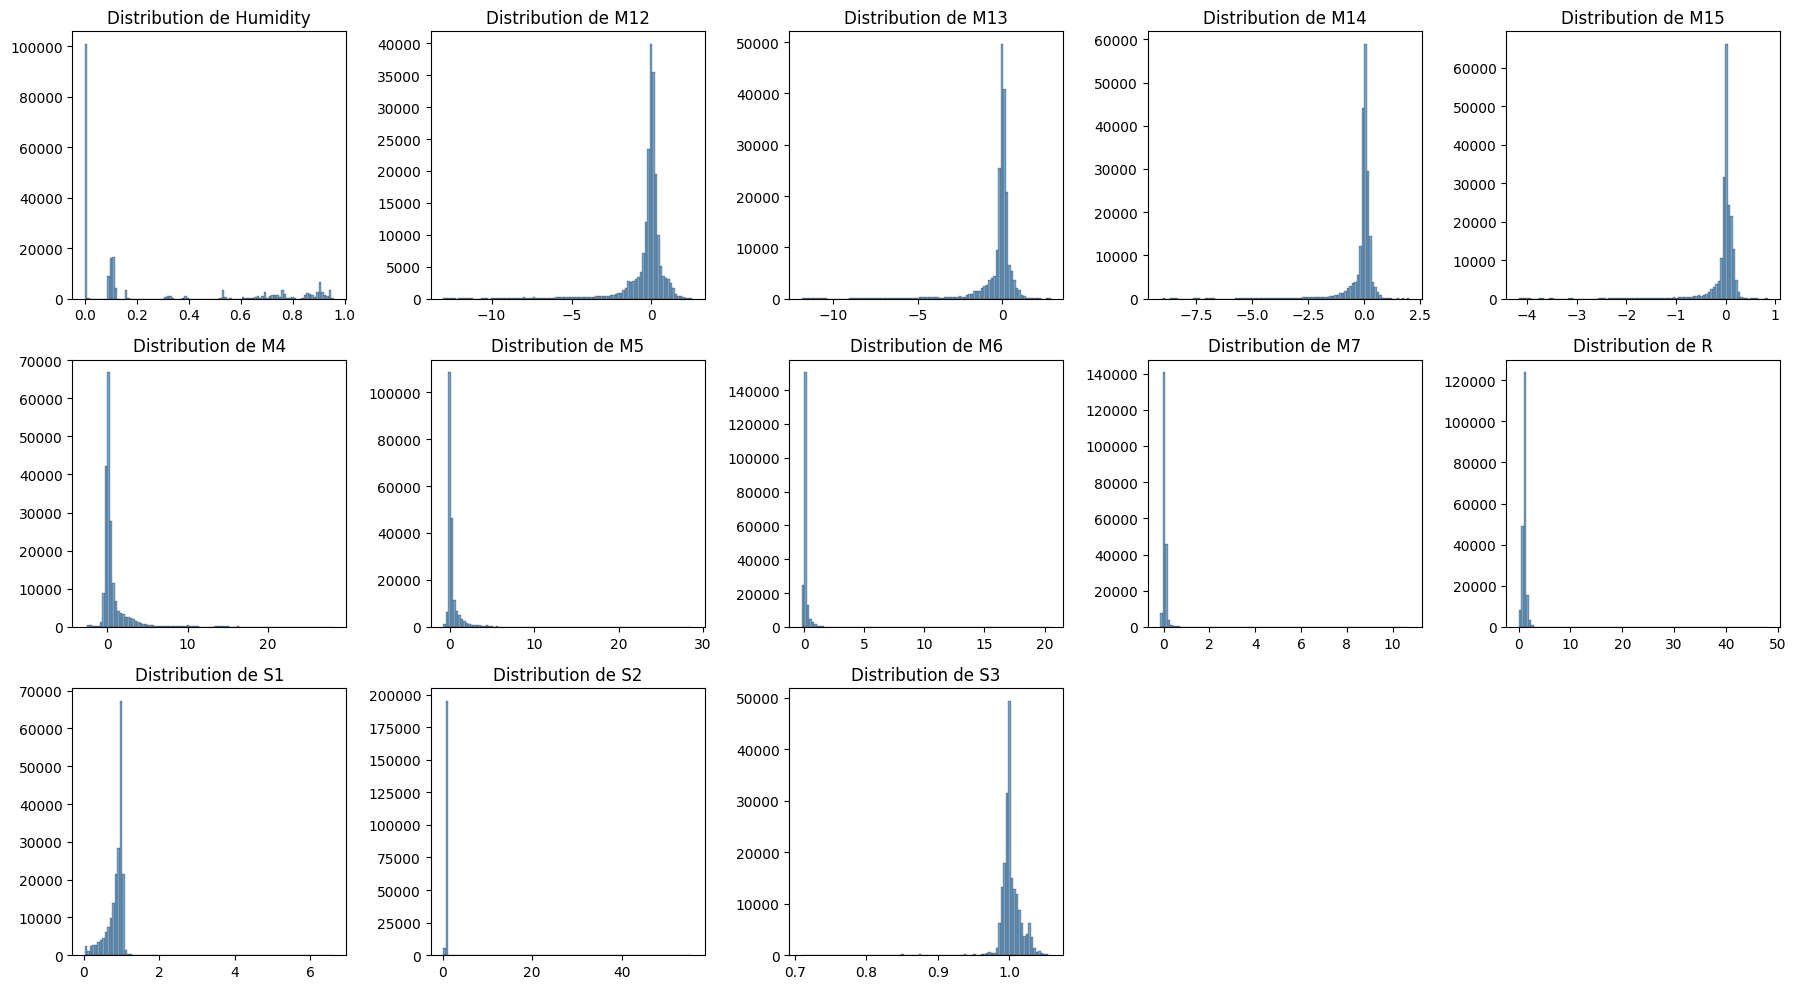

In [11]:
# Granularité des capteurs (Distribution détaillée des features)
# Affichage sous forme d'histogrammes avec 100 'bins' (très fin) pour voir les détails de la répartition
feature_cols = [c for c in X_train.columns if c != 'ID']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(X_train[col], bins=100, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

# Masquer les cases vides
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

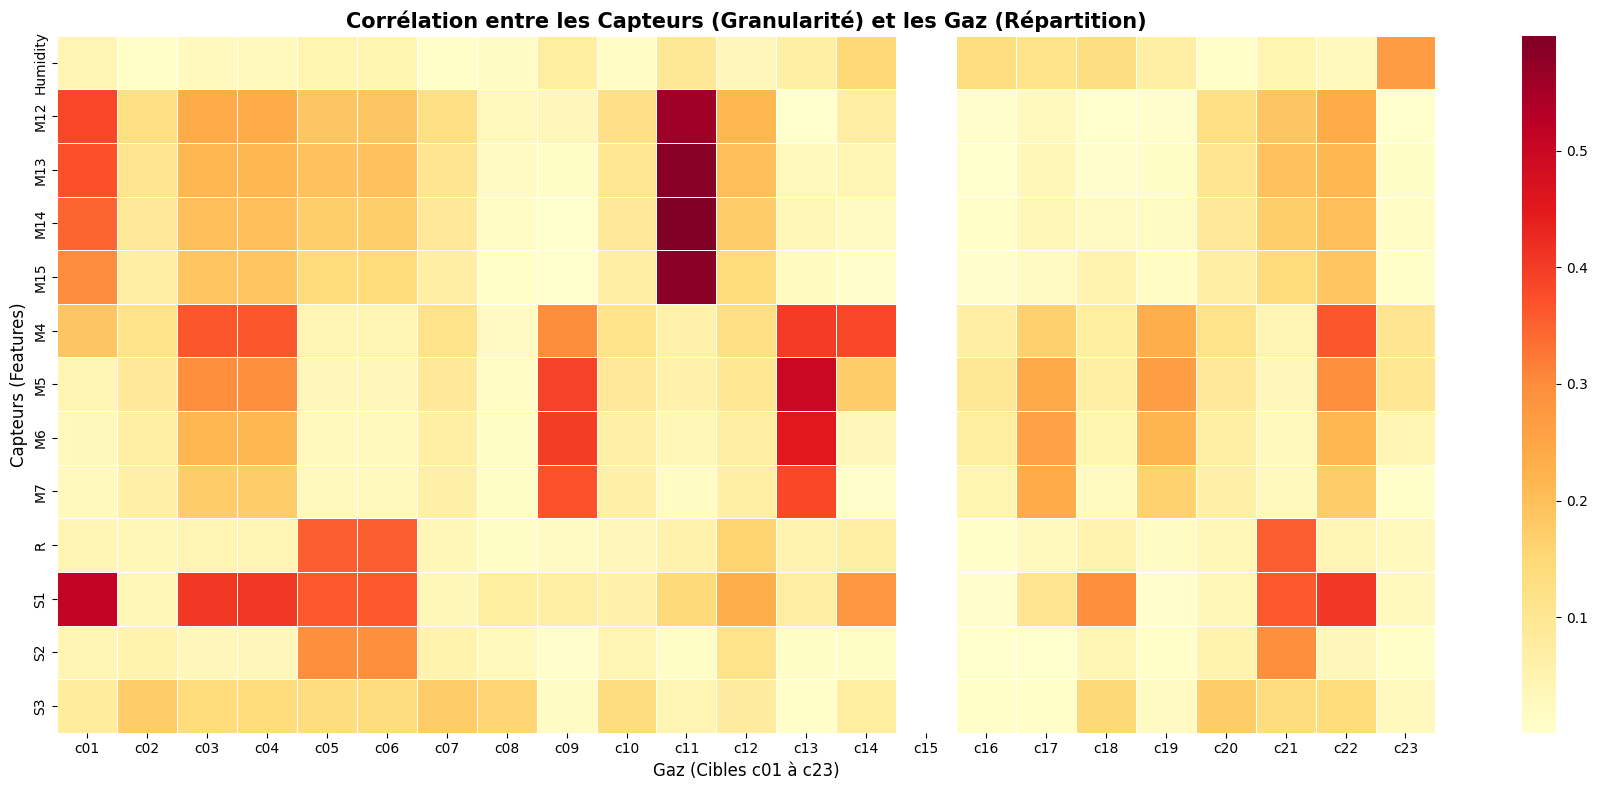

In [12]:
# Corrélation entre la granularité des capteurs et la répartition des gaz
# Nous allons fusionner temporairement les deux tableaux pour calculer la corrélation (la force du lien)
# entre chaque capteur et chaque gaz.
Xy = pd.concat([X_train[feature_cols].reset_index(drop=True), y_train[target_cols].reset_index(drop=True)], axis=1)

# On calcule la corrélation en valeur absolue pour bien voir l'intensité du lien (qu'il soit positif ou négatif)
feat_target_corr = Xy.corr().loc[feature_cols, target_cols].abs()

fig, ax = plt.subplots(figsize=(18, 8))
# Création d'une carte de chaleur (Heatmap). Plus la couleur est foncée, plus le capteur réagit à ce gaz.
sns.heatmap(feat_target_corr, cmap='YlOrRd', linewidths=0.5, ax=ax)

ax.set_title('Corrélation entre les Capteurs (Granularité) et les Gaz (Répartition)', fontsize=15, fontweight='bold')
ax.set_xlabel('Gaz (Cibles c01 à c23)', fontsize=12)
ax.set_ylabel('Capteurs (Features)', fontsize=12)
plt.tight_layout()
plt.show()

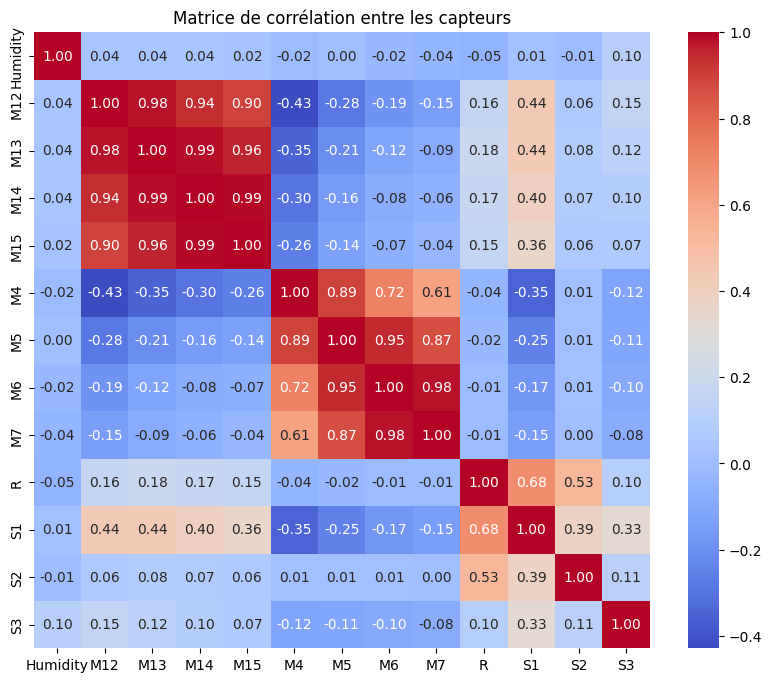

In [13]:
# --- NOUVEAUX GRAPHIQUES ULTRA UTILES --- #

# 1. Corrélation entre les capteurs eux-mêmes (Multicolinéarité)
# Ce graphique permet d'identifier si plusieurs capteurs donnent exactement la même information.
# Si la corrélation approche 1 ou -1, cela indique une forte redondance.

plt.figure(figsize=(10, 8))
corr_capteurs = X_train.drop(columns=['ID']).corr()
sns.heatmap(corr_capteurs, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('Matrice de corrélation entre les capteurs')
plt.show()


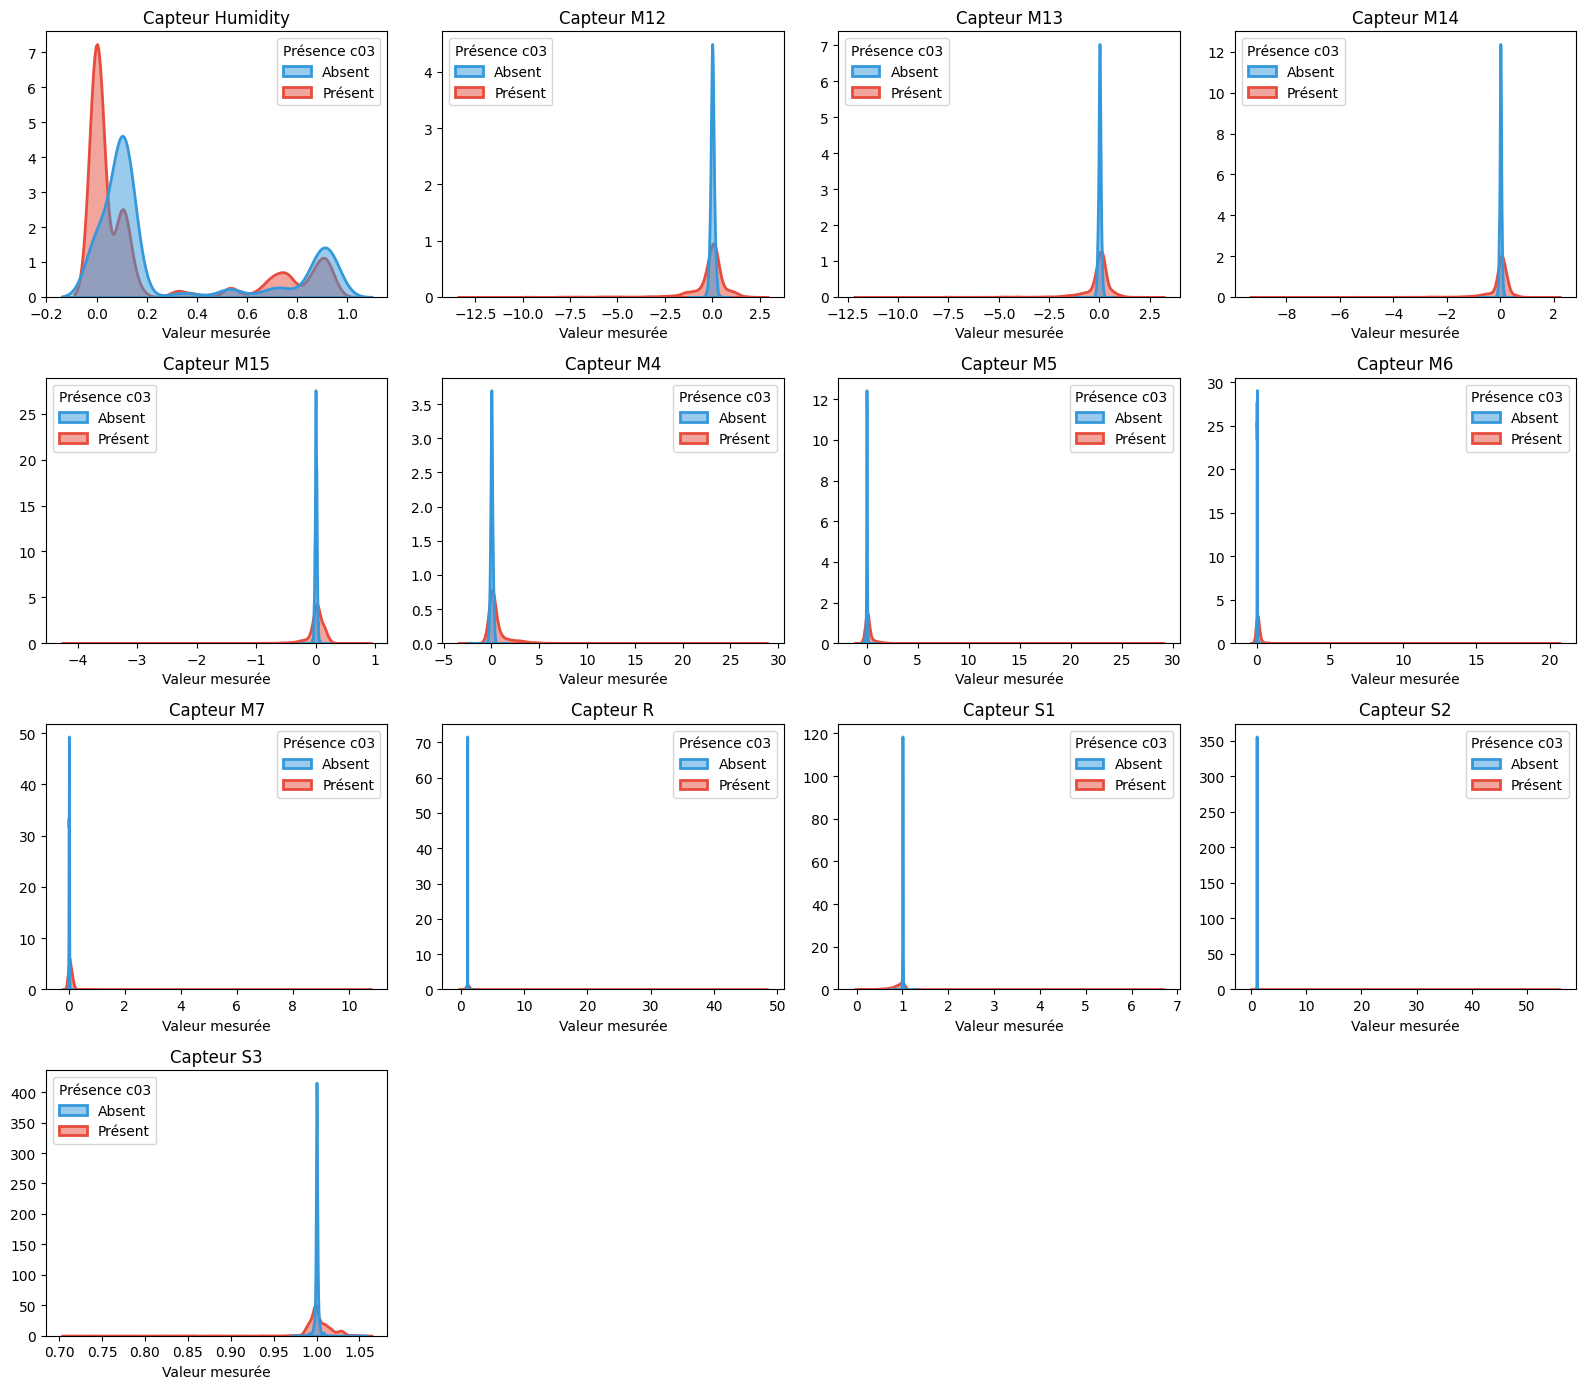

In [15]:
# 2. Courbes de densité (plus parlant) pour le gaz c03
# Ici, on dessine deux "montagnes" pour chaque capteur :
# - Bleu : Le gaz c03 est ABSENT
# - Rouge : Le gaz c03 est PRÉSENT
# Si les deux montagnes se superposent parfaitement, le capteur ne sert à rien pour ce gaz.
# Si elles sont décalées, le capteur réagit très bien !

plot_data = X_train.copy()
# Création d'une colonne texte pour une légende claire
plot_data['Présence c03'] = y_train['c03'].apply(lambda x: 'Présent' if x > 0 else 'Absent')

plt.figure(figsize=(16, 14))
capteurs = [col for col in X_train.columns if col != 'ID']

for i, capteur in enumerate(capteurs, 1):
    plt.subplot(4, 4, i)
    # kdeplot trace les courbes de densité (les "montagnes")
    sns.kdeplot(data=plot_data, x=capteur, hue='Présence c03', fill=True, common_norm=False, palette=['#3498db', '#e74c3c'], alpha=0.5, linewidth=2)
    plt.title(f'Capteur {capteur}')
    plt.xlabel('Valeur mesurée')
    plt.ylabel('')

plt.tight_layout()
plt.show()


In [22]:
# Assure-toi que dfY est un array 2D (n_samples, 23)
y = y_train.values
X = X_train.values

# Split train/val (80/20)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)